In [73]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import contextily as cx
from datetime import datetime, date, timedelta
import seaborn as sns
import shapely

In [74]:
gdf_track_info = gpd.read_parquet("../data/track_info.parquet")
gdf_track_info

,track_file,track_file_datetime,track_file_date,start_datetime,end_datetime,year,season,total_duration,total_distance (mi),average_pace (min/mi),total_elevation_change (m),in_stc,start_point,end_point,track_line
0,/Users/ryansponzilli/Developer/Python Projects...,2019-06-10 07:46:00,2019-06-10,2019-06-10 11:57:42+00:00,2019-06-10 12:46:10+00:00,Freshman,Summer Training,0 days 00:48:28,3.063156,8.542777,77.126862,True,POINT (-88.32154 41.91101),POINT (-88.32166 41.9109),"MULTILINESTRING ((-88.32154 41.91101, -88.3215..."
1,/Users/ryansponzilli/Developer/Python Projects...,2019-06-11 07:32:00,2019-06-11,2019-06-11 11:59:03+00:00,2019-06-11 12:32:23+00:00,Freshman,Summer Training,0 days 00:33:20,3.172008,8.767494,122.178753,True,POINT (-88.34764 41.928),POINT (-88.34792 41.92783),"MULTILINESTRING ((-88.34764 41.928, -88.34764 ..."
2,/Users/ryansponzilli/Developer/Python Projects...,2019-06-12 07:35:00,2019-06-12,2019-06-12 11:53:30+00:00,2019-06-12 12:35:13+00:00,Freshman,Summer Training,0 days 00:41:43,3.052702,8.581829,132.038013,True,POINT (-88.32152 41.91252),POINT (-88.32172 41.911),"MULTILINESTRING ((-88.32152 41.91252, -88.3215..."
3,/Users/ryansponzilli/Developer/Python Projects...,2019-06-17 07:22:00,2019-06-17,2019-06-17 11:52:32+00:00,2019-06-17 12:22:32+00:00,Freshman,Summer Training,0 days 00:30:00,2.983042,9.088904,86.000490,True,POINT (-88.32145 41.911),POINT (-88.32154 41.91096),"MULTILINESTRING ((-88.32145 41.911, -88.32143 ..."
4,/Users/ryansponzilli/Developer/Python Projects...,2019-06-18 07:19:00,2019-06-18,2019-06-18 11:53:58+00:00,2019-06-18 12:19:21+00:00,Freshman,Summer Training,0 days 00:25:23,2.355063,9.380388,95.971917,True,POINT (-88.35416 41.92575),POINT (-88.34797 41.92783),"MULTILINESTRING ((-88.35416 41.92575, -88.3541..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1018,/Users/ryansponzilli/Developer/Python Projects...,2023-05-04 15:10:00,2023-05-04,2023-05-04 19:54:31+00:00,2023-05-04 20:10:21+00:00,Senior,Track Season,0 days 00:15:50,2.032107,7.547855,23.622665,True,POINT (-88.27989 41.92867),POINT (-88.27976 41.92838),"MULTILINESTRING ((-88.27989 41.92867, -88.2798..."
1019,/Users/ryansponzilli/Developer/Python Projects...,2023-05-04 15:42:00,2023-05-04,2023-05-04 20:24:15+00:00,2023-05-04 20:42:07+00:00,Senior,Track Season,0 days 00:17:52,0.999846,5.064146,8.642043,True,POINT (-88.27658 41.92845),POINT (-88.27658 41.92851),"MULTILINESTRING ((-88.27658 41.92845, -88.2765..."
1020,/Users/ryansponzilli/Developer/Python Projects...,2023-05-05 15:11:00,2023-05-05,2023-05-05 19:44:31+00:00,2023-05-05 20:11:23+00:00,Senior,Track Season,0 days 00:26:52,3.509378,6.976707,43.772437,True,POINT (-88.27988 41.92846),POINT (-88.27952 41.9282),"MULTILINESTRING ((-88.27988 41.92846, -88.2798..."
1021,/Users/ryansponzilli/Developer/Python Projects...,2023-05-06 11:15:00,2023-05-06,2023-05-06 15:58:42+00:00,2023-05-06 16:15:16+00:00,Senior,Track Season,0 days 00:16:34,1.985944,7.678578,38.987511,True,POINT (-88.32198 41.95005),POINT (-88.32167 41.95012),"MULTILINESTRING ((-88.32198 41.95005, -88.3219..."


In [75]:
pause_line = gdf_track_info.loc[gdf_track_info['start_datetime'] > pd.to_datetime(datetime(2023, 2, 7), utc=True)].iloc[0]
pause_line

track_file                    /Users/ryansponzilli/Developer/Python Projects...
track_file_datetime                                         2023-02-07 15:48:00
track_file_date                                                      2023-02-07
start_datetime                                        2023-02-07 21:13:31+00:00
end_datetime                                          2023-02-07 21:48:21+00:00
year                                                                     Senior
season                                                             Track Season
total_duration                                                  0 days 00:34:50
total_distance (mi)                                                    4.031597
average_pace (min/mi)                                                  7.449723
total_elevation_change (m)                                            36.773228
in_stc                                                                     True
start_point                             

In [76]:
def parse_gpx(gpx_file):
    gdf = gpd.read_file(gpx_file, layer="track_points")
    gdf = gdf[["time", "ele", "geometry"]]
    gdf["time"] = pd.to_datetime(gdf["time"])
    gdf = gdf.rename(columns={"time": "datetime", "ele": "elevation"})
    gdf["elapsed_time"] = gdf["datetime"].diff().cumsum()
    gdf["elapsed_time"] = gdf["elapsed_time"].fillna(timedelta(seconds=0))
    gdf["elapsed_distance (mi)"] = (
        gdf.to_crs(gdf.estimate_utm_crs())["geometry"]
        .distance(gdf.to_crs(gdf.estimate_utm_crs())["geometry"].shift())
        .cumsum()
        / 1609
    )
    gdf["elapsed_distance (mi)"] = gdf["elapsed_distance (mi)"].fillna(0)
    gdf["pace (min/mi)"] = (gdf["elapsed_time"].dt.total_seconds() / 60).diff(10) / gdf[
        "elapsed_distance (mi)"
    ].diff(10)
    gdf["pace (min/mi)"] = gdf["pace (min/mi)"].bfill()
    return gdf[
        [
            "datetime",
            "elapsed_time",
            "elapsed_distance (mi)",
            "pace (min/mi)",
            "elevation",
            "geometry",
        ]
    ]

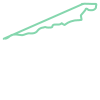

In [77]:
pause_line['track_line']

In [78]:
gdf = parse_gpx(pause_line['track_file'])
gdf

,datetime,elapsed_time,elapsed_distance (mi),pace (min/mi),elevation,geometry
0,2023-02-07 21:13:31+00:00,0 days 00:00:00,0.000000,22.421649,236.657103,POINT (-88.27581 41.9252)
1,2023-02-07 21:13:32+00:00,0 days 00:00:01,0.000746,22.421649,236.608273,POINT (-88.27581 41.92519)
2,2023-02-07 21:13:33+00:00,0 days 00:00:02,0.001607,22.421649,236.587713,POINT (-88.2758 41.92518)
3,2023-02-07 21:13:34+00:00,0 days 00:00:03,0.002500,22.421649,236.484079,POINT (-88.27578 41.92517)
4,2023-02-07 21:13:35+00:00,0 days 00:00:04,0.003393,22.421649,236.343193,POINT (-88.27577 41.92516)
...,...,...,...,...,...,...
1264,2023-02-07 21:48:01+00:00,0 days 00:34:30,4.027708,11.447533,236.178369,POINT (-88.27561 41.92513)
1265,2023-02-07 21:48:02+00:00,0 days 00:34:31,4.028649,12.141602,236.162441,POINT (-88.27562 41.92512)
1266,2023-02-07 21:48:19+00:00,0 days 00:34:48,4.030728,30.770230,236.100960,POINT (-88.27559 41.92514)
1267,2023-02-07 21:48:20+00:00,0 days 00:34:49,4.031248,33.456406,236.110269,POINT (-88.27558 41.92514)


<Axes: >

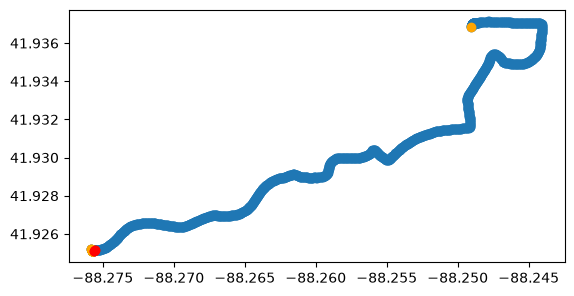

In [79]:
fig, ax = plt.subplots()
gdf.plot(ax=ax)
gdf[0:48].plot(ax=ax, color='orange')
gdf[-5:-1].plot(ax=ax, color='red')

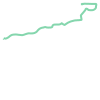

In [80]:
# get diffs column to detect outliers which indicate a pause
diffs = gdf.to_crs(gdf.estimate_utm_crs())["geometry"].distance(gdf.to_crs(gdf.estimate_utm_crs())["geometry"].shift())[1::]
# calculate outlier threshold
t = 10*np.std(diffs)
# get outlier indices
split_idx = diffs[diffs > t].index
# split linestring at pauses
segments = []
prev_i = 0
for i in split_idx:
    segments.append(gdf.iloc[prev_i:i]['geometry'])
    prev_i = i
segments.append(gdf.iloc[prev_i::]['geometry'])
# recombine as multilinestring
shapely.MultiLineString([shapely.LineString(c) for c in segments])

In [ ]:
def fix_run_pauses(series):
    fixed_tracks = []
    for gpx_file in series:
        gdf = gpd.read_file(gpx_file, layer="track_points")
        # get diffs column to detect outliers which indicate a pause
        gdf_utm = gdf.to_crs(gdf.estimate_utm_crs())
        diffs = gdf_utm["geometry"].distance(gdf_utm["geometry"].shift())[1::]
        # calculate outlier threshold
        t = np.mean(diffs) + 10*np.std(diffs)
        # get outlier indices
        split_idx = diffs[diffs > t].index


        # split linestring at pauses
        segments = []
        prev_idx = 0
        for idx in split_idx:
            if (idx - prev_idx) < 2:
                continue
            segments.append(gdf.iloc[prev_idx:idx]['geometry'])
            prev_idx = idx
        
        # always add last segment
        last_segment = gdf.iloc[prev_idx::]['geometry']
        if len(last_segment) > 1:
            segments.append(last_segment)
        
        # recombine as multilinestring
        fixed_tracks.append(shapely.MultiLineString([shapely.LineString(c) for c in segments]))
    return fixed_tracks

gdf_track_info['track_line'] = gdf_track_info['track_file'].apply(fix_run_pauses)
gdf_track_info

In [ ]:
gdf_track_info['track_line'] = gdf_track_info['track_file'].apply(fix_run_pauses)
gdf_track_info

0       MULTILINESTRING ((-88.321538 41.911011, -88.32...
1       MULTILINESTRING ((-88.34764 41.928004, -88.347...
2       MULTILINESTRING ((-88.321522 41.912519, -88.32...
3       MULTILINESTRING ((-88.32145 41.911, -88.321426...
4       MULTILINESTRING ((-88.354158 41.925746, -88.35...
                              ...                        
1018    MULTILINESTRING ((-88.279886 41.928667, -88.27...
1019    MULTILINESTRING ((-88.276577 41.928447, -88.27...
1020    MULTILINESTRING ((-88.279884 41.92846, -88.279...
1021    MULTILINESTRING ((-88.321983 41.950053, -88.32...
1022    MULTILINESTRING ((-88.279806 41.924238, -88.27...
Name: track_file, Length: 1023, dtype: object

In [103]:
gdf_track_info

,track_file,track_file_datetime,track_file_date,start_datetime,end_datetime,year,season,total_duration,total_distance (mi),average_pace (min/mi),total_elevation_change (m),in_stc,start_point,end_point,track_line
0,/Users/ryansponzilli/Developer/Python Projects...,2019-06-10 07:46:00,2019-06-10,2019-06-10 11:57:42+00:00,2019-06-10 12:46:10+00:00,Freshman,Summer Training,0 days 00:48:28,3.063156,8.542777,77.126862,True,POINT (-88.32154 41.91101),POINT (-88.32166 41.9109),"MULTILINESTRING ((-88.32154 41.91101, -88.3215..."
1,/Users/ryansponzilli/Developer/Python Projects...,2019-06-11 07:32:00,2019-06-11,2019-06-11 11:59:03+00:00,2019-06-11 12:32:23+00:00,Freshman,Summer Training,0 days 00:33:20,3.172008,8.767494,122.178753,True,POINT (-88.34764 41.928),POINT (-88.34792 41.92783),"MULTILINESTRING ((-88.34764 41.928, -88.34764 ..."
2,/Users/ryansponzilli/Developer/Python Projects...,2019-06-12 07:35:00,2019-06-12,2019-06-12 11:53:30+00:00,2019-06-12 12:35:13+00:00,Freshman,Summer Training,0 days 00:41:43,3.052702,8.581829,132.038013,True,POINT (-88.32152 41.91252),POINT (-88.32172 41.911),"MULTILINESTRING ((-88.32152 41.91252, -88.3215..."
3,/Users/ryansponzilli/Developer/Python Projects...,2019-06-17 07:22:00,2019-06-17,2019-06-17 11:52:32+00:00,2019-06-17 12:22:32+00:00,Freshman,Summer Training,0 days 00:30:00,2.983042,9.088904,86.000490,True,POINT (-88.32145 41.911),POINT (-88.32154 41.91096),"MULTILINESTRING ((-88.32145 41.911, -88.32143 ..."
4,/Users/ryansponzilli/Developer/Python Projects...,2019-06-18 07:19:00,2019-06-18,2019-06-18 11:53:58+00:00,2019-06-18 12:19:21+00:00,Freshman,Summer Training,0 days 00:25:23,2.355063,9.380388,95.971917,True,POINT (-88.35416 41.92575),POINT (-88.34797 41.92783),"MULTILINESTRING ((-88.35416 41.92575, -88.3541..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1018,/Users/ryansponzilli/Developer/Python Projects...,2023-05-04 15:10:00,2023-05-04,2023-05-04 19:54:31+00:00,2023-05-04 20:10:21+00:00,Senior,Track Season,0 days 00:15:50,2.032107,7.547855,23.622665,True,POINT (-88.27989 41.92867),POINT (-88.27976 41.92838),"MULTILINESTRING ((-88.27989 41.92867, -88.2798..."
1019,/Users/ryansponzilli/Developer/Python Projects...,2023-05-04 15:42:00,2023-05-04,2023-05-04 20:24:15+00:00,2023-05-04 20:42:07+00:00,Senior,Track Season,0 days 00:17:52,0.999846,5.064146,8.642043,True,POINT (-88.27658 41.92845),POINT (-88.27658 41.92851),"MULTILINESTRING ((-88.27658 41.92845, -88.2765..."
1020,/Users/ryansponzilli/Developer/Python Projects...,2023-05-05 15:11:00,2023-05-05,2023-05-05 19:44:31+00:00,2023-05-05 20:11:23+00:00,Senior,Track Season,0 days 00:26:52,3.509378,6.976707,43.772437,True,POINT (-88.27988 41.92846),POINT (-88.27952 41.9282),"MULTILINESTRING ((-88.27988 41.92846, -88.2798..."
1021,/Users/ryansponzilli/Developer/Python Projects...,2023-05-06 11:15:00,2023-05-06,2023-05-06 15:58:42+00:00,2023-05-06 16:15:16+00:00,Senior,Track Season,0 days 00:16:34,1.985944,7.678578,38.987511,True,POINT (-88.32198 41.95005),POINT (-88.32167 41.95012),"MULTILINESTRING ((-88.32198 41.95005, -88.3219..."
